<a href="https://colab.research.google.com/github/smitp2705/maths_pr2/blob/main/maths_pr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df=pd.read_csv("/content/student_dataset.csv")
df

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,15,85,Yes,78,Pass
1,10,60,No,55,Fail
2,20,95,Yes,88,Pass
3,8,50,No,45,Fail
4,18,90,Yes,82,Pass
5,5,40,No,35,Fail
6,22,92,Yes,91,Pass
7,12,70,Yes,65,Pass
8,7,55,No,48,Fail
9,25,98,Yes,95,Pass


In [6]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,15,85,Yes,78,Pass
1,10,60,No,55,Fail
2,20,95,Yes,88,Pass
3,8,50,No,45,Fail
4,18,90,Yes,82,Pass


In [7]:
Total = len(df)
event1 = df[df["study_hours"] > 10]
event2 = df[df["attendance"] > 80]
event3 = df[df["final_exam_pass"] == "Pass"]

print("Probability")
print("(study_hours > 10):", len(event1)/Total)
print("(attendance > 80):", len(event2)/Total)
print("(pass):", len(event3)/Total)

Probability
(study_hours > 10): 0.625
(attendance > 80): 0.4
(pass): 0.575


In [9]:
empirical_pass = len(event3) / Total

theoretical_prob = 0.5

print("Empirical vs Theoretical ")
print("Empirical P(pass):", empirical_pass)
print("Theoretical example (coin):", theoretical_prob)

Empirical vs Theoretical 
Empirical P(pass): 0.575
Theoretical example (coin): 0.5


In [10]:
#  RANDOM VARIABLE

# X = number of students passing out of 3 selected
p = empirical_pass

# Binomial Distribution
from math import comb

prob_dist = {}
for x in range(4):
    prob = comb(3, x) * (p**x) * ((1-p)**(3-x))
    prob_dist[x] = prob

print("Probability Distribution")
for k, v in prob_dist.items():
    print(f"P(X={k}) = {v:.4f}")

# Mean and Variance
mean = 3 * p
variance = 3 * p * (1 - p)

print("\nMean:", mean)
print("Variance:", variance)

Probability Distribution
P(X=0) = 0.0768
P(X=1) = 0.3116
P(X=2) = 0.4215
P(X=3) = 0.1901

Mean: 1.7249999999999999
Variance: 0.733125


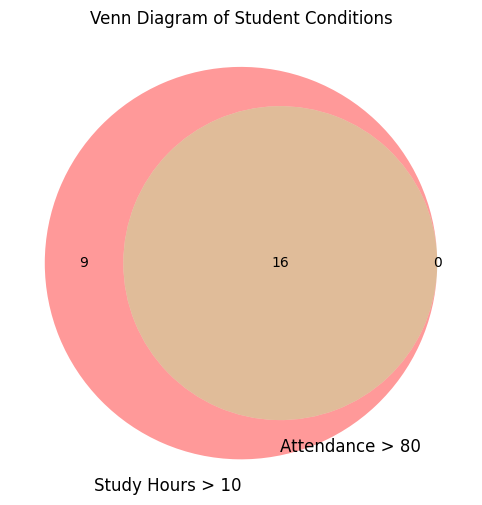

In [11]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# Conditions
A = df["study_hours"] > 10
B = df["attendance"] > 80

# Calculate regions
only_A = sum(A & ~B)
only_B = sum(B & ~A)
both_AB = sum(A & B)

# Draw Venn Diagram
plt.figure(figsize=(6,6))

venn2(
    subsets=(only_A, only_B, both_AB),
    set_labels=("Study Hours > 10", "Attendance > 80")
)

plt.title("Venn Diagram of Student Conditions")
plt.show()

In [12]:
ct = pd.crosstab(df["group_discussion"], df["final_exam_pass"])
print("\n--- Contingency Table ---\n", ct)

# Joint probability
joint = ct.loc["Yes", "Pass"] / Total

# Marginal probability
marginal = ct["Pass"].sum() / Total

# Conditional probability
conditional = ct.loc["Yes", "Pass"] / ct.loc["Yes"].sum()

print(" P(Discussion AND Pass):", joint)
print("Marginal P(Pass):", marginal)
print("Conditional P(Pass | Discussion):", conditional)


--- Contingency Table ---
 final_exam_pass   Fail  Pass
group_discussion            
No                  17     0
Yes                  0    23
 P(Discussion AND Pass): 0.575
Marginal P(Pass): 0.575
Conditional P(Pass | Discussion): 1.0


In [13]:
# 7. RELATIONSHIP
p_discussion = ct.loc["Yes"].sum() / Total

if abs(joint - (p_discussion * marginal)) < 0.05:
    print("\nEvents are approximately Independent")
else:
    print("\nEvents are Dependent")


Events are Dependent


In [14]:
#  BAYES THEOREM
P_H_given_pass = 0.7
P_H_given_fail = 0.4
P_H = 0.6

P_pass = empirical_pass
P_fail = 1 - P_pass

# Total probability of H
P_H_calc = (P_H_given_pass * P_pass) + (P_H_given_fail * P_fail)

# Bayes formula
P_pass_given_H = (P_H_given_pass * P_pass) / P_H_calc

print("Bayes Theorem ")
print("P(Pass | High Attendance):", P_pass_given_H)

Bayes Theorem 
P(Pass | High Attendance): 0.7030567685589519
